# Bad Honnef Exoplanetary School
## Exoplanets Ground-based Transmission spectroscopy

In order to perform exoplanet transmission spectroscopy from the ground one obtains simultaneous time-series spectra of the exoplanet host star and a number of reference stars, within the same field of view. Reference stars are required to correct for atmospheric effects on the transit light curves, which otherwise would be very difficult to model and remove. These effects are due to the gradual change in the airmass of the field, as well as short term variability in the atmospheric turbulence.

In this practical exercise, we will now go through an example of obtaining an exoplanet transmission spectrum. As already explained, this is a spectrum of the exoplanet size as a function of wavelength, whose variability depends on the atmospheric constituents and properties of the transiting planet. The observations have already been reduced and the spectra of the exoplanet host star during the transit, as well as the reference stars are saved as pickle files, which you can get from the school's Github repository.

The observations have been made with the [FORS2](https://www.eso.org/sci/facilities/paranal/instruments/fors/overview.html) instrument at the VLT, in its multi-object spectroscopy mode ([MXU](https://www.eso.org/sci/facilities/paranal/instruments/fors/inst/mxu.html)), and there are 6 datasets in total; 3 transit of [WASP-39b](https://exoplanet.eu/catalog/wasp_39_b--818/) and 3 transits of [WASP-52b](https://exoplanet.eu/catalog/wasp_52_b--918/), each taken once with the [600B, 600RI and 600z grisms](https://www.eso.org/sci/facilities/paranal/instruments/fors/inst/grisms.html), together covering the entire visible range.

Here are the steps that you are expected to take to obtain the transmission spectrum from these spectra:

1.   Clone the school's [GitHub](https://github.com/bh-atmospheres/summer-schoool-2025/) respository
2.   Read the data using the ${\tt pickle}$ python module, and familiarize yourself with the data structure (dictionaries)
3.   Plot single spectra of the stars for each dataset to decide on a common wavelength range for integration
4.   Integrate the spectra within that range to obtain light curves (LC), and plot them (normalize to exposure time)
5.   Divide the LC of the exoplanet host by the reference stars, and decide on the best choice
6.   Normalize this differential LC by fitting an appropriate polynomial to the out of transit data
7.   Model this broadband (white) LC using the analytical transit model of [Madel & Agol (2002)](https://ui.adsabs.harvard.edu/abs/2002ApJ...580L.171M/abstract), implemented in python (e.g. [${\tt exoplanet}$](https://docs.exoplanet.codes/en/v0.4.3/tutorials/transit/), [${\tt PyTransit}$](https://github.com/hpparvi/PyTransit), [${\tt batman}$](https://lkreidberg.github.io/batman/docs/html/index.html), etc.), obtaining parameter solutions by using MCMC or Nested Sampling to derive posterior distributions (Bayesian Framework)
8.   Obtain narrowband LCs by integrating the spectra again with 100 or 200$\,$Å bins
9.   Remove common mode systematics through dividing these LCs by the residuals of the white LC fit.
10.   Model these LCs, but this time fixing those non-wavelenegth dependant parameters to the results obtained from the broadband LC fit
11.  Plot the transmission spectrum, i.e. $R_p/R_\star$ as the function of $\lambda$





In [ ]:
# Step 1: cloning the respository
!git clone https://github.com/bh-atmospheres/summer-schoool-2025/
!pip install mpld3 # interactive matplotlib widget

Cloning into 'summer-schoool-2025'...
remote: Enumerating objects: 222, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 222 (delta 16), reused 23 (delta 9), pack-reused 160 (from 1)
Receiving objects: 100% (222/222), 226.76 MiB | 14.96 MiB/s, done.
Resolving deltas: 100% (100/100), done.
Updating files: 100% (51/51), done.
Error downloading object: pRT/input_data_BH.zip (b63df60): Smudge error: Error downloading pRT/input_data_BH.zip (b63df60f7d000aa6c0bb48aa1da1dd348f39126274ed8b74d77dc111cdc6b1c2): batch response: This repository exceeded its LFS budget. The account responsible for the budget should increase it to restore access.

Errors logged to /content/summer-schoool-2025/.git/lfs/logs/20250722T144321.803004559.log
Use `git lfs logs last` to view the log.
error: external filter 'git-lfs filter-process' failed
fatal: pRT/input_data_BH.zip: smudge filter lfs failed
You can inspect what was checked out with 'git stat

In [ ]:
# Step 2: reading the data
import pickle
dic = pickle.load(open('/content/summer-schoool-2025/FORS2/WASP-52_600z.pkl','rb'))
dic.keys()

dict_keys(['sp1', 'sp2', 'sp3', 'seeing', 'airmass', 'exp_time', 'MJD-OBS', 'wvl'])

In [ ]:
!pip install mpld3
# Step 3: visualizing the data
import matplotlib.pyplot as plt
import mpld3
from mpld3 import plugins
import warnings
warnings.filterwarnings("ignore")

for key in ['sp1','sp2','sp3']:
  plt.plot(dic['wvl'], dic[key][0], lw=1.5, label=key)
plt.legend()
plt.ylabel('Counts')
plt.xlabel('Wavelength [Angstrom]')
mpld3.display()

In [ ]:
# Step 4: integrating the spectra to obtain LCs
import numpy as np
from scipy.integrate import quad
from scipy.interpolate import interp1d

# Define integration bounds
x1  = dic['wvl'][0]
x2  = 10300

wvl = dic['wvl']
LCs = []
for key in ['sp1','sp2','sp3']:
  lc = []
  for f in dic[key]:
    y_interp = interp1d(wvl, f, kind='linear', bounds_error=False, fill_value=0.0)

    integ, _ = quad(y_interp, x1, x2)
    lc.append(integ)
  LCs.append(lc)

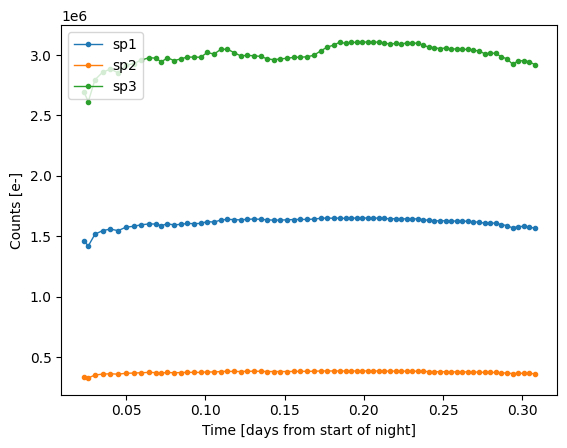

In [ ]:
# plot normalized LCs
GAIN = 0.58 # conversion from ADUs to electrons
t    = np.array(dic['MJD-OBS'])+np.array(dic['exp_time'])/(2.*3600.*24) # Get mid-exposure times
t    = t - int(t[-1])
t    = t[:-2]
for i,lc in enumerate(LCs):
  plt.plot(t, np.array(lc)[:-2]/GAIN, '.-', lw=1, label='sp%i'%(i+1))
plt.ylabel('Counts [e-]')
plt.xlabel('Time [days from start of night]')
plt.legend()

In [ ]:
t

array([0.02343255, 0.02625053, 0.03043982, 0.03532354, 0.04020852,
       0.04509224, 0.04997722, 0.05486106, 0.05974604, 0.06463195,
       0.06883152, 0.07232653, 0.07616981, 0.08035904, 0.08456093,
       0.08875032, 0.09294082, 0.09713017, 0.10132064, 0.10551014,
       0.10971197, 0.11390129, 0.11810358, 0.12229263, 0.12648311,
       0.13067986, 0.13487457, 0.13907536, 0.14326586, 0.14746709,
       0.15168861, 0.1558811 , 0.16007218, 0.16429108, 0.16848649,
       0.17270522, 0.17690085, 0.18111929, 0.18496843, 0.18847432,
       0.19199907, 0.19549986, 0.19899638, 0.20249097, 0.2059987 ,
       0.20950506, 0.21302687, 0.21653156, 0.2200547 , 0.22355647,
       0.22705348, 0.230559  , 0.2340556 , 0.23756206, 0.24108571,
       0.24458675, 0.24811412, 0.25161211, 0.25513643, 0.25863794,
       0.26213514, 0.26565826, 0.26916133, 0.27268433, 0.2761865 ,
       0.27971733, 0.28324339, 0.28676739, 0.29027253, 0.29379677,
       0.29729744, 0.30079209, 0.30431444, 0.30781757])

In [ ]:
# Step 5: create differential LCs
d_LC1  = np.array(LCs[2])[:-2]/np.array(LCs[0])[:-2]
d_LC1 /= np.mean(d_LC1)
d_LC2  = np.array(LCs[2])[:-2]/np.array(LCs[1])[:-2]
d_LC2 /= np.mean(d_LC2)
d_LC3  = np.array(LCs[2])[:-2]/(np.array(LCs[0])[:-2]+np.array(LCs[1])[:-2])
d_LC3 /= np.mean(d_LC3)
# calculate relative errors assuming Poisson noise (sqrt(photons) ) - only considering the flux from WASP-52
e_LC = 1./np.sqrt(LCs[2][:-2]) * np.sqrt(GAIN)

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(t, d_LC1, 'o', ms=3, label='/sp1, sig=%.6f'%np.std(d_LC1), c='C0')
plt.plot(t, d_LC2+0.01, 'o', ms=3, label='/sp2, sig=%.6f'%np.std(d_LC2), c='C1')
plt.plot(t, d_LC3+0.02, 'o', ms=3, label='/(sp1+sp2), sig=%.6f'%np.std(d_LC3), c='C3')
plt.legend()
mpld3.display()

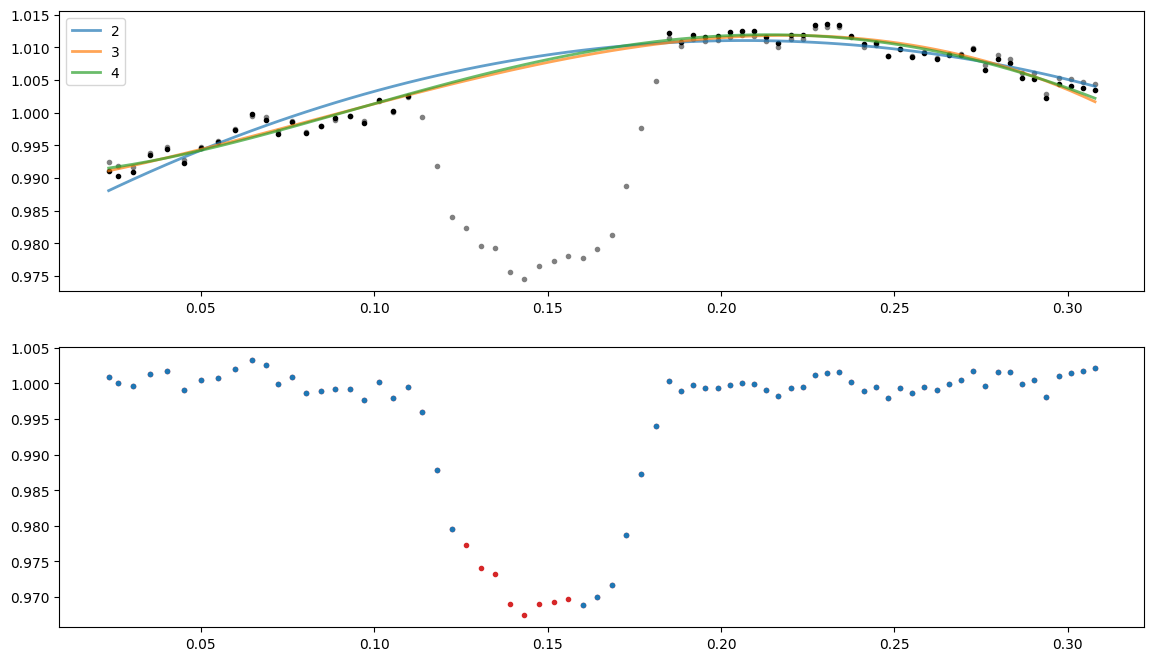

In [ ]:
# Step 6: normalizing to out of transit trend (hint: try multiple polynomial orders)
t1        = 0.112        # transit start
t2        = 0.184        # transit end
f_oot     = d_LC1[np.logical_or(t<t1,t>t2)]
t_oot     = t[np.logical_or(t<t1,t>t2)]
fig, (ax0, ax1) = plt.subplots(2,1, figsize=(14,8))
ax0.plot(t, d_LC3, 'o', c='grey', ms=3)
ax0.plot(t_oot, f_oot, 'o', c='k', ms=3)
for poly_order in [2,3,4]:
  oot_model = np.poly1d(np.polyfit(t_oot, f_oot, poly_order))
  ax0.plot(t, oot_model(t), lw=2, alpha=0.7, label=poly_order)
ax0.legend()
poly_order= 4 # make a decision about the order of polynomial
oot_model = np.poly1d(np.polyfit(t_oot, f_oot, poly_order))
ax1.plot(t, d_LC3/oot_model(t), 'o', ms=3,c='C3')
F_ = d_LC3/oot_model(t)
# masking in-transit data points affected by spot-crossing event (WASP-52b, 600z)
t1_  = 0.125
t2_  = 0.160
F    = F_[np.logical_or(t<t1_,t>t2_)]
T    = t[np.logical_or(t<t1_,t>t2_)]
e_LC = e_LC[np.logical_or(t<t1_,t>t2_)]
ax1.plot(T,F,'o',ms=3,c='C0')

In [ ]:
# Step 7: fitting the broadband transit LC with a transit model
!pip install batman-package  # for an analytical model of a transit
!pip install emcee           # for running MCMC
!pip install corner          # for plotting corner plots
!pip install ldtk            # for calculating LD coefficients

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 1.9 MB/s eta 0:00:00


In [ ]:
# calculate limb darkening coefficients for the star, given the wavelength of observations
from ldtk import LDPSetCreator, BoxcarFilter

filters = [BoxcarFilter('a', x1/10., x2/10.)] # needs to be in microns

sc = LDPSetCreator(teff=(6000,   100),
                   logg=(4.582, 0.20),
                      z=(0.030, 0.01),
                     filters=filters)

ps = sc.create_profiles()
cq,eq = ps.coeffs_qd()
print('u1 = %.5f, u2 = %.5f'%(cq[0][0],cq[0][1]))

Updating server file list:   0%|          | 0/9 [00:00<?, ?it/s]

Need to download 118 files, approximately 39.41 MB


LDTk downloading uncached files:   0%|          | 0/118 [00:00<?, ?it/s]

u1 = 0.34971, u2 = 0.16432


In [ ]:
import batman
PER = 1.74977083 # define period as hardcoded
def transit_model_full(theta, t):
  """
  wrapper for defining a transit model with all parameters free
  """
  t0, rp, a, inc, u1, u2 = theta
  params     = batman.TransitParams()
  params.t0  = t0
  params.per = PER
  params.rp  = rp
  params.a   = a
  params.inc = inc
  params.u   = [u1, u2]
  params.limb_dark = "quadratic"
  params.ecc = 0
  params.w   = 90.
  m          = batman.TransitModel(params, t, supersample_factor = 7, exp_time = round(np.median(dic['exp_time']))/(24.*3600.))
  lc         = m.light_curve(params)

  return lc

t_= np.linspace(T[0],T[-1],endpoint=True,num=1000)
plt.figure(figsize=(14,5))
plt.plot(t, F_, '.', c='red', ms=6, label='Masked')
plt.errorbar(T, F, yerr=e_LC*F, fmt='.k', ms=6)
params = [0.148, 0.173, 7.38, 85.35, cq[0][0], cq[0][1]] # initial guess values for the free parameters
plt.plot(t_, transit_model_full(params, t_), lw=2, alpha=0.7, label='Initial guess model')
plt.xlabel('Time - 24%i [MJD]'%dic['MJD-OBS'][-1])
plt.ylabel('Normalized Flux')
plt.legend()
mpld3.display()

ModuleNotFoundError: No module named 'batman'

## Bayesian parameter estimation

The system characterisation is a parameter estimation problem, where we assume we have an adequate model to describe the observations, and we want to infer the model parameters with their uncertainties. This model was discussed in the lecture earlier.

We take a [Bayesian](http://en.wikipedia.org/wiki/Bayesian_probability) approach to parameter estimation, where we want to estimate the [posterior probability](http://en.wikipedia.org/wiki/Posterior_probability) for the model parameters given their [prior probabilities](http://en.wikipedia.org/wiki/Prior_probability) and a set of observations. The posterior probability density given a parameter vector $\theta$ and observational data $D$ is described by [Bayes' theorem](http://en.wikipedia.org/wiki/Bayes%27_theorem) as:

$$ P(\theta | D ) = \frac{P(\theta)P(D|\theta)}{P(D)} $$

where $P(\theta)$ is the prior, $P(D|\theta)$ is the [likelihood](http://en.wikipedia.org/wiki/Likelihood_function) for the data, and $P(D)$ is a [normalising factor](http://en.wikipedia.org/wiki/Marginal_likelihood) that we don't care about during MCMC-based parameter estimation. This is because be work with derivatives (for miminization) and the derivative of a constant is 0.

The likelihood is a product of individual observation probabilities, and has the unfortunate tendency to end up being either very small or very big. This causes computational headaches, and it is better to work with log probabilities instead. Taking the logarithm of the Bayesian relation above has the added advantage of converting the division to addition which is much easier to differentiate:

$$
\log P(\theta|D) = \log P(\theta) + \log P(D|\theta),  \qquad \textrm{with} \quad \log P(D|\theta) = \sum \log P(D_i|\theta)
$$

This is to say that $\log (posterior) = \log(prior) + \log(likelihood)$.  Note that we left out "$-\log P(D)$" since its derivate will be 0.

### The likelihood

Now we need to decide on the form of the likelihood density function. If we can assume [normally distributed](https://en.wikipedia.org/wiki/Normal_distribution) white noise--that is, the errors in the observations are independent and identically distributed--we end up with a log likelihood function:

$$
 \log P(D|\theta) = -N\log(\sigma) -\frac{N\log 2\pi}{2} - \sum_{i=0}^N \frac{(o_i-m_i)^2}{2\sigma^2_i},
$$

where $N$ is the number of datapoints, $\sigma$ is the white noise standard deviation, $o$ is the observed data, and $m$ is the model. (I hope that it is clear that the above relation is just the logarithm of the Gaussian function.)

**Note: Unfortunately, the noise is rarely white, and contains systematic components from instrumental and astrophysical sources that should be accounted for by a noise model for robust parameter estimation. A widely used, non-parametric approach to modeling correlated (red) noise is using the Gaussian Processes (GPs), which is unfortunately beyond the scope of this school.**

In [ ]:
import emcee
# functions for calculating the Bayesian relation
def log_likelihood(theta, t, flux, flux_err):
    t0, rp, a, inc, u1, u2 = theta
    model_flux = transit_model_full(theta, t)
    return -0.5 * np.sum(((flux - model_flux) / flux_err) ** 2)

def log_prior(theta):
  t0, rp, a, inc, u1, u2 = theta
  if not (0.13 < t0  < 0.17 and 0.15 < rp < 0.19 and 5 < a < 9 and 80. < inc < 90. and 0 <= u1 <= 1 and -1 <= u2 <= 1):
      return -np.inf
  ln_prior_u1 = -0.5 * ((u1 - cq[0][0]) / eq[0][0]) ** 2
  ln_prior_u2 = -0.5 * ((u2 - cq[0][1]) / eq[0][1]) ** 2
  return ln_prior_u1 + ln_prior_u2

def log_posterior(theta, t, flux, flux_err):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, flux, flux_err)

# initializing the walkers
ndim     = len(params)
nwalkers = 18
pos      = [params + 1e-4*np.random.randn(ndim) for i in range(nwalkers)]

# define the sampler and run MCMC
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(T, F, e_LC*F))
sampler.run_mcmc(pos, 10000, progress=True)

In [ ]:
# flatten chains
samples = sampler.get_chain(discard=2000, thin=15, flat=True)
fig, axes = plt.subplots(6,1)
for i,ax in enumerate(axes):
  ax.plot(samples[:,i], lw=1, c='grey', alpha=0.5)

In [ ]:
# plot posterior distributions
from corner import corner
fig = corner(samples, labels=["t0", "rp/rs", "a", "i", "u1", "u2"], fill_contours=True, show_titles=True,)
fig.set_size_inches(7,7)
plt.show()

In [ ]:
# Plot best-fit model
best_fit_w = np.median(samples, axis=0)
t0, rp, a, inc, u1, u2 = best_fit_w
best_flux  = transit_model_full(best_fit_w, t_)

fig, (ax0, ax1) = plt.subplots(2,1,figsize=(14,5),height_ratios=[5,1])
ax0.plot(24*(t-t0), F_, ".r", label="Masked")
ax0.errorbar(24*(T-t0), F, yerr=e_LC*F, fmt=".k", label="Data")
ax0.plot(24*(t_-t0), best_flux, "C0", label="Best-fit")

# optional: draw random results from the samples to obtain model uncertainties, for visual purposes.
draw     = np.floor(np.random.uniform(0,len(samples),size=1000)).astype(int)
thetas   = samples[draw]
models   = []
for i in thetas:
  t0, rp, a, inc, u1, u2 = i
  models.append(transit_model_full(i, t_))
spread = np.std(models,axis=0)
#med_model = np.median(models,axis=0)

ax0.fill_between(24*(t_-t0),best_flux-3*spread,best_flux+3*spread,color='grey',alpha=0.5,label=r'$3\sigma$ Posterior Spread')
ax0.set_ylabel("Relative Flux")
ax0.legend()
# calculate residuals of the model
residuals  = F_ / transit_model_full(best_fit_w, t)
ax1.axhline(1.0, lw=1, c='grey', alpha=0.8)
ax1.plot(24*(t-t0), residuals, ".k", label="Residuals")
ax1.set_ylabel("O-C")
ax1.set_xlabel("Time from mid-transit [hours]")

In [ ]:
# Steps 8, 9 & 10: Obtain spectral LCs, remove common mode residuals and model them, fitting only wavelength-dependent parameters

def transit_model_spec(theta, t):

  rp, u1, u2 = theta
  params           = batman.TransitParams()
  params.t0        = best_fit_w[0]
  params.per       = PER
  params.rp        = rp
  params.a         = best_fit_w[2]
  params.inc       = best_fit_w[3]
  params.u         = [u1, u2]
  params.limb_dark = "quadratic"
  params.ecc       = 0.
  params.w         = 90.
  m                = batman.TransitModel(params, t, supersample_factor = 7, exp_time = round(np.median(dic['exp_time']))/(24.*3600.))
  lc               = m.light_curve(params)

  return lc

offset = 0.
TS     = []
fig, (ax0, ax1) = plt.subplots(1,2, figsize=(12,9))
ax0.set_ylabel('Normalized flux (+offset)')
ax1.set_ylabel('O - C (+offset)')
ax0.set_xlabel('Time [hours from mid-transit]')
ax1.set_xlabel('Time [hours from mid-transit]')
ax0.set_title('CMC Spectroscopic light curves')
ax1.set_title('Model residuals')
for x1 in np.arange(7371,10100,step=200):
  print('Processing the bin centered on %i'%(x1+100))
  x2  = x1 + 200

  wvl = dic['wvl']
  LCs = []
  for key in ['sp3','sp1']:
    lc = []
    for f in dic[key]:
      y_interp = interp1d(wvl, f, kind='linear', bounds_error=False, fill_value=0.0)

      integ, _ = quad(y_interp, x1, x2)
      lc.append(integ)
    LCs.append(lc)

  d_LC      = np.array(LCs[0][:-2])/np.array(LCs[1][:-2])
  d_LC     /= np.mean(d_LC)
  e_LC      = 1./np.sqrt(LCs[0][:-2]) * np.sqrt(GAIN)

  d_LC     /= residuals

  f_oot     = d_LC[np.logical_or(t<t1,t>t2)]
  oot_model = np.poly1d(np.polyfit(t_oot, f_oot, poly_order))
  F_        = d_LC/oot_model(t)

  # masking in-transit data points affected by spot-crossing event (WASP-52b, 600z)
  # commented out since we make the (wrong) assumption that the spot-crossing does not
  # change with wavelength, so common mode correction removes it.
  #F    = F_[np.logical_or(t<t1_,t>t2_)]
  #e_LC = e_LC[np.logical_or(t<t1_,t>t2_)]

  # calculate limb darkening coefficients for the wavelengths of each bin
  filter = [BoxcarFilter('a', x1/10., x2/10.)]

  sc = LDPSetCreator(teff=(6000,   100),
                     logg=(4.582, 0.20),
                        z=(0.030, 0.01),
                      filters=filter)

  ps = sc.create_profiles()
  cq,eq = ps.coeffs_qd()

  # redefine Bayesian relation
  def log_likelihood(theta, t, flux, flux_err):
      rp, u1, u2 = theta
      model_flux = transit_model_spec(theta, t)
      return -0.5 * np.sum(((flux - model_flux) / flux_err) ** 2)

  def log_prior(theta):
    rp, u1, u2 = theta
    if not (0.155 < rp < 0.185 and 0 <= u1 <= 1 and -1 <= u2 <= 1):
        return -np.inf
    ln_prior_u1 = -0.5 * ((u1 - cq[0][0]) / (3*eq[0][0])) ** 2
    ln_prior_u2 = -0.5 * ((u2 - cq[0][1]) / (3*eq[0][1])) ** 2
    return ln_prior_u1 + ln_prior_u2

  def log_posterior(theta, t, flux, flux_err):
      lp = log_prior(theta)
      if not np.isfinite(lp):
          return -np.inf
      return lp + log_likelihood(theta, t, flux, flux_err)

  # parameter starting point & walker initiation
  initial    = [best_fit_w[1], cq[0][0], cq[0][1]]
  ndim       = len(initial)
  nwalkers   = 10
  pos        = [initial + 1e-6*np.random.randn(ndim) for i in range(nwalkers)]

  # run sampler
  sampler    = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(t, F_, e_LC*F_))
  sampler.run_mcmc(pos, 5000, progress=True)

  # flatten the chains to get the samples
  samples = sampler.get_chain(discard=2000, thin=15, flat=True)

  # obtain best fit parameters
  best_fit_s = np.median(samples, axis=0)
  rp, u1, u2 = best_fit_s
  best_flux  = transit_model_spec(best_fit_s, t_)

  # plot spectroscopic light curves, together with best fit models
  ax0.errorbar(24*(t-t0), F_+offset, yerr=e_LC*F_, fmt=".k", zorder=1)
  ax0.plot(24*(t_-t0), best_flux+offset, c="C0", lw=2, alpha=0.8, zorder=2)

  # plot the residuals of each fit
  ax1.errorbar(24*(t-t0), F_-transit_model_spec(best_fit_s, t)+1.+offset, yerr=e_LC*F_, fmt=".k", zorder=2, alpha=0.8)
  ax1.axhline(1.+offset, c="C0", lw=2, zorder=1)

  offset += 0.02

  # store bin information and planet radius results, together with their errors into an array
  TS.append(np.array([float(x1+100),rp,np.percentile(samples,16,axis=0)[0]-rp,np.percentile(samples,84,axis=0)[0]-rp,np.std(samples,axis=0)[0]]))


In [ ]:
# Step 11: Obtain and plot the transmission spectrum
TS = np.array(TS)
plt.figure(figsize=(14,6))
plt.title('WASP-52b transmission spectrum -- GRIS_600z')
plt.plot(TS[:,0], TS[:,1], '.', ms=3)
plt.errorbar(TS[:,0], TS[:,1], yerr=(abs(TS[:,2]),TS[:,3]), fmt='o')
#plt.errorbar(TS[:,0], TS[:,1], yerr=TS[:,4], fmt='o', c='red')
plt.ylabel('Rp/Rs')
plt.xlabel('Wavelength [angstrom]')